# S&P 500 Options: Model Analysis

This notebook describes the complete official validation prediction populations produced by the
model execution notebooks. Model identity always includes family, configuration, and checkpoint.
Every comparison requires identical expected prediction keys and the same cross-validation
identity. Information coefficient and related diagnostics do not select a model or checkpoint.

Causal DML is reported separately because it estimates a treatment effect rather than a
cross-sectional prediction configuration.

**Why completeness is established before any number is read.** Every table here is a comparison,
and a comparison across populations that do not cover the same rows is not a comparison at all:
a model scored on an easier subset of the panel looks better for a reason that has nothing to do
with the model. So the notebook refuses before it reports. It requires each prediction to be
complete against its own registered eligibility contract, and requires the four populations to
share one cross-validation identity, because two models cut on different folds have seen
different training data and their diagnostics are not on one scale.

**What a reader gets from this page.** A description of what was fitted and how the resulting
predictions behave, at the grain the pipeline actually decides on, which is the configuration
and its checkpoint together. What a reader does not get is a winner. Nothing here is ranked and
nothing here is chosen; that happens downstream, on backtests, and the separation is deliberate.

In [1]:
"""Analyze complete S&P 500 options model populations."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import CausalResult, PredictionResult, Result
from case_studies.sp500_options.research_workflow import (
    official_prediction_catalog,
    open_study,
)

MODEL_POPULATIONS = (
    "sp500-options-linear-validation-v1",
    "sp500-options-gbm-validation-v1",
    "sp500-options-tabular-dl-validation-v1",
    "sp500-options-sequence-validation-v1",
)

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## Complete population and its eligibility groups

Named immutable populations replace hash lists and registry-presence filters. The coverage table
comes from each prediction result's registered eligibility contract.

The four populations share one CV identity but not one eligibility set. A sequence model scores a
symbol only after its lookback window is available, so it is eligible on fewer symbols and fewer
rows than the cross-sectional families reading the same panel. The audit below reports one row per
eligibility group rather than asserting a single one, and the diagnostics that follow are read
within a group.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = official_prediction_catalog(study, MODEL_POPULATIONS)

coverage_rows = []
for prediction_hash in catalog.get_column("prediction_hash"):
    result = Result.open(study, prediction_hash)
    if not isinstance(result, PredictionResult):
        raise TypeError(f"{prediction_hash} is not a prediction result")
    coverage = result.coverage()
    if coverage is None or coverage["status"] != "complete":
        raise RuntimeError(f"prediction {prediction_hash} has incomplete coverage")
    coverage_rows.append(
        {
            "prediction_hash": prediction_hash,
            "expected_key_digest": coverage["expected_key_digest"],
            "n_expected": coverage["n_expected"],
            "n_actual": coverage["n_actual"],
            "n_folds": coverage["n_folds_actual"],
        }
    )
coverage = pl.DataFrame(coverage_rows)

cv_identities = catalog.get_column("cv_identity").drop_nulls()
if cv_identities.is_empty() or cv_identities.n_unique() != 1:
    raise RuntimeError("official model populations do not share one CV identity")

Eligibility is grouped, not assumed identical. A sequence model needs a lookback window before it
can score a symbol, so it is eligible on strictly fewer rows than a cross-sectional model reading
the same panel - which is a property of the model class, not a defect. Requiring one eligibility
digest across all four populations would fail here for a correct run. What must hold is that every
prediction sharing an eligibility contract agrees on its dimensions exactly.

**The grouping is what makes the diagnostics readable rather than misleading.** Two checkpoints
in the same group were scored on identical rows, so the difference between their numbers is the
models. Two checkpoints in different groups were not, and the difference between those numbers
is the models and the rows together, with no way to separate them from this table. The audit
below prints one row per group so that a reader can see which comparisons are available before
making one, rather than discovering afterwards that a sequence model was scored on the subset
of the panel where a lookback window existed.

In [4]:
coverage = coverage.join(
    catalog.select("prediction_hash", "family"), on="prediction_hash", how="left"
)
for digest, group in coverage.group_by("expected_key_digest"):
    if group.select("n_expected", "n_actual", "n_folds").n_unique() != 1:
        raise RuntimeError(
            f"predictions sharing eligibility {digest[0]} disagree on coverage dimensions"
        )
    if group.filter(pl.col("n_actual") != pl.col("n_expected")).height:
        raise RuntimeError(f"eligibility {digest[0]} has predictions short of their declaration")

population_audit = (
    coverage.group_by("expected_key_digest")
    .agg(
        pl.col("family").unique().sort().str.join(", ").alias("families"),
        pl.len().alias("predictions"),
        pl.col("n_expected").first().alias("rows_per_prediction"),
        pl.col("n_folds").first().alias("folds"),
    )
    .with_columns(pl.lit(cv_identities[0]).alias("cv_identity"))
    .sort("rows_per_prediction", descending=True)
)
if population_audit.get_column("predictions").sum() != catalog.height:
    raise RuntimeError("the eligibility audit does not account for every declared prediction")
population_audit

expected_key_digest,families,predictions,rows_per_prediction,folds,cv_identity
str,str,u32,i64,i64,str
"""82ad3bdca2dea91f""","""gbm, linear, tabular_dl""",202,135709,2,"""b622d62ada7be6bb"""
"""d7ecf93df4204754""","""deep_learning""",60,42804,2,"""b622d62ada7be6bb"""


## Predictive diagnostics

The table retains each checkpoint as a separate row. It supports descriptive comparison only;
strategy selection occurs after every row has an equal-weight validation backtest.

**What the four columns are.** The information coefficient is the rank correlation between a
model's predictions and the realised label, computed across the symbols priced at one decision
time and then averaged over decision times. `ic_mean` is that average, `ic_std` its dispersion
across decision times, and `ic_t` the ratio of the two scaled by the number of decision times,
so it asks whether the mean is distinguishable from zero rather than whether it is large.
`pct_positive` is the share of decision times whose IC exceeded zero, which separates a model
that is mildly right most of the time from one carried by a few large periods.

**Rank correlation is the point of the choice.** It is invariant to any increasing transform of
the predictions, so a model whose values are badly scaled but correctly ordered scores the same
as one that is calibrated, and a squared-error fit is not rewarded for matching the magnitude of
a heavy tail it was never going to match. What that invariance costs is any information about
the size of the move, which is the reason the number below cannot stand in for a return.

**Why none of it selects.** A rank correlation says nothing about whether the ordering survives
position sizing, turnover and cost, and those are what decide whether a strategy makes money.
Selection is therefore by best validation backtest Sharpe, taken over configurations that each
already have an equal-weight backtest, with the checkpoint part of the configuration's identity
rather than a detail of how it was fitted. A high IC here is a reason to look, never a result.

Each IC is computed on its own prediction's eligible rows, so two rows are directly comparable
only when the same eligibility group above covers both. A sequence checkpoint and a linear
checkpoint are scored on different populations, and the difference between their IC values
therefore mixes model behaviour with the population each was scored on.

In [5]:
analysis = (
    catalog.with_columns(
        pl.when(pl.col("checkpoint_value").is_null())
        .then(pl.col("checkpoint_kind").fill_null("final"))
        .otherwise(
            pl.concat_str(
                pl.col("checkpoint_kind"),
                pl.col("checkpoint_value").cast(pl.String),
                separator="=",
            )
        )
        .alias("checkpoint"),
    )
    .with_columns(
        pl.concat_str(
            "family",
            "config_name",
            "checkpoint",
            separator=" / ",
        ).alias("model_identity")
    )
    .select(
        "family",
        "config_name",
        "checkpoint",
        "model_identity",
        "ic_mean",
        "ic_std",
        "ic_t",
        "pct_positive",
        "prediction_hash",
    )
    .sort("family", "config_name", "checkpoint")
)
if analysis.select("ic_mean", "ic_std", "ic_t", "pct_positive").null_count().sum_horizontal().sum():
    raise RuntimeError("official model population has missing regression diagnostics")
analysis

family,config_name,checkpoint,model_identity,ic_mean,ic_std,ic_t,pct_positive,prediction_hash
str,str,str,str,f64,f64,f64,f64,str
"""deep_learning""","""lstm_h64""","""epoch=10""","""deep_learning / lstm_h64 / epo…",0.002791,0.024313,0.162367,0.5,"""dc7c1c94149d"""
"""deep_learning""","""lstm_h64""","""epoch=100""","""deep_learning / lstm_h64 / epo…",-0.001806,0.025866,-0.098746,0.5,"""0846f5b4ea04"""
"""deep_learning""","""lstm_h64""","""epoch=15""","""deep_learning / lstm_h64 / epo…",-0.002921,0.016977,-0.243358,0.5,"""821e026c54b7"""
"""deep_learning""","""lstm_h64""","""epoch=20""","""deep_learning / lstm_h64 / epo…",0.002646,0.027711,0.135061,0.5,"""065609cdbb3c"""
"""deep_learning""","""lstm_h64""","""epoch=25""","""deep_learning / lstm_h64 / epo…",0.001012,0.035783,0.039985,0.5,"""309998677536"""
…,…,…,…,…,…,…,…,…
"""tabular_dl""","""tabm_s""","""epoch=175""","""tabular_dl / tabm_s / epoch=17…",0.000568,0.006326,0.127041,0.5,"""40712973224e"""
"""tabular_dl""","""tabm_s""","""epoch=200""","""tabular_dl / tabm_s / epoch=20…",0.00057,0.006549,0.123163,0.5,"""bcbb3b1f27d7"""
"""tabular_dl""","""tabm_s""","""epoch=25""","""tabular_dl / tabm_s / epoch=25""",-0.010369,0.013747,-1.066647,0.5,"""cdd18f90149a"""


In [6]:
family_summary = (
    analysis.group_by("family")
    .agg(
        pl.len().alias("configuration_checkpoints"),
        pl.col("ic_mean").min().alias("ic_min"),
        pl.col("ic_mean").median().alias("ic_median"),
        pl.col("ic_mean").max().alias("ic_max"),
    )
    .sort("family")
)
family_summary

family,configuration_checkpoints,ic_min,ic_median,ic_max
str,u32,f64,f64,f64
"""deep_learning""",60,-0.021348,-0.002007,0.016036
"""gbm""",150,-0.016858,-0.005095,0.003467
"""linear""",28,-0.018483,-0.015019,-0.002348
"""tabular_dl""",24,-0.010369,0.000938,0.008856


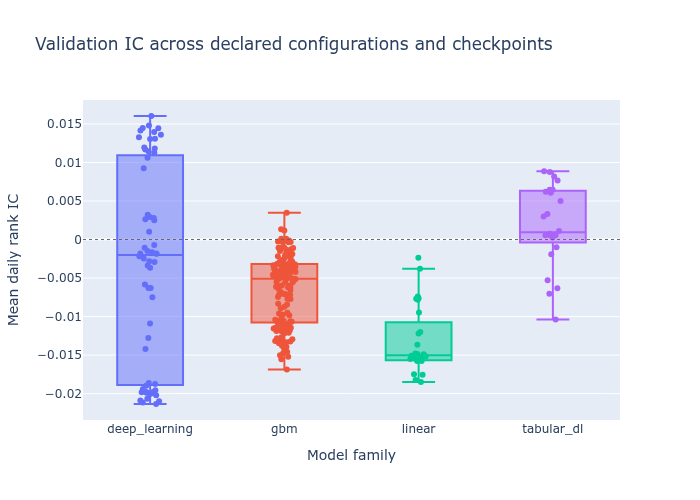

In [7]:
fig = go.Figure()
for family in analysis.get_column("family").unique(maintain_order=True):
    rows = analysis.filter(pl.col("family") == family)
    fig.add_trace(
        go.Box(
            name=family,
            y=rows.get_column("ic_mean").to_list(),
            text=rows.get_column("model_identity").to_list(),
            boxpoints="all",
            jitter=0.35,
            pointpos=0,
            hovertemplate="%{text}<br>validation IC %{y:+.4f}<extra></extra>",
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="#666666")
fig.update_layout(
    title="Validation IC across declared configurations and checkpoints",
    xaxis_title="Model family",
    yaxis_title="Mean daily rank IC",
    showlegend=False,
)
fig.show()

## Causal DML artifact

The causal result is not mixed into the predictive population or its checkpoint summaries.

**It answers a different question from everything above.** The models above rank symbols against
each other at a decision time; the estimate below asks what happens to the outcome when the
treatment moves, holding the controls fixed. Double machine learning gets there by fitting two
nuisance models - one predicting the outcome from the controls, one predicting the treatment
from them - and regressing the parts neither explains against each other, so that the effect is
estimated on what is left after the controls are accounted for rather than on the raw series.

**Two standard errors are reported and they are not interchangeable.** The HAC standard error
corrects for the serial correlation that overlapping labels induce, which is what makes the
conventional error too small on this data. The placebo p-value is a permutation test: the
treatment is shuffled in blocks long enough to preserve that serial dependence, the estimate is
recomputed, and the reported value is the share of shuffles reaching the observed effect. The
first asks whether the estimate is distinguishable from zero given the dependence; the second
asks whether the procedure would have produced it from a treatment that carries no signal.

It is resolved as canonical whatever tier this notebook runs at, because the populations above
are canonical whatever tier this notebook runs at. Asking a preview run for a preview causal
artifact would make the notebook fail unless `10_causal_dml` happened to have run in the same
workspace first, and would pair a preview estimate with canonical predictions if it had.

In [8]:
causal = CausalResult.one(study, label="ret_to_expiry", execution_tier="canonical")
if not causal.complete:
    raise RuntimeError("the causal DML artifact is incomplete")
causal_summary = pl.DataFrame(
    {
        "causal_hash": [causal.hash],
        "treatment": [causal.spec["computation"]["estimand"]["treatment"]],
        "outcome": [causal.spec["computation"]["estimand"]["outcome"]],
        "observations": [causal.metrics["n_obs"]],
        "effect": [causal.metrics["dml_effect"]],
        "hac_standard_error": [causal.metrics["dml_se_hac"]],
        "hac_p_value": [causal.metrics["p_value_hac"]],
        "placebo_p_value": [causal.metrics["refutation_p"]],
    }
)
causal_summary

causal_hash,treatment,outcome,observations,effect,hac_standard_error,hac_p_value,placebo_p_value
str,str,str,i64,f64,f64,f64,f64
"""3498c82ad588""","""vrp_21d""","""ret_to_expiry""",166105,0.409777,0.350872,0.243225,0.009901


Predictive diagnostics and the causal estimate are now available for reader inspection. Neither
table changes the complete prediction population or selects a strategy.

**Reading the two tables together, and the trap in doing so.** They describe the same data from
two directions, and neither confirms the other. A family can rank symbols well and carry no
causal effect on the treatment studied here, because ranking exploits any stable association
while the estimate is restricted to what survives the controls. The reverse also happens: a
treatment effect that is real and small can be invisible to a rank correlation computed across
a cross-section it barely moves. Agreement between the two is worth noticing and is not
evidence, and disagreement is not a defect in either.

**What carries forward.** Only the population itself. The diagnostics are read and left here;
the next stage takes every configuration in the population, gives each an equal-weight backtest,
and selects on that. Anything a reader concludes from the numbers above should be held until
those backtests exist, because the ordering above and the ordering there routinely differ.